# Business Intelligence Analysis

## ApexPlanet Data Analytics Internship

### Task 2: Exploratory Data Analysis & Business Intelligence

---

## Objective

The objective of this notebook is to transform exploratory findings into actionable business intelligence by answering key business questions using descriptive analytics and visualization.

The analysis focuses on identifying business performance trends, customer behavior, product performance, geographic sales distribution, and strategic recommendations that support data-driven decision-making.

---

## Business Questions

This notebook aims to answer the following questions:

1. What is the overall business performance?
2. Which products generate the highest revenue?
3. Which product categories contribute the most revenue?
4. Which cities generate the highest revenue?
5. Which customer age group contributes the highest sales?
6. Who are the highest-value customers?
7. How do sales change over time?
8. What strategic recommendations can improve business performance?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

# Load Dataset

The cleaned dataset generated during Task 1 is loaded for Business Intelligence analysis.

In [2]:
df = pd.read_csv("../data/processed/cleaned_dataset.csv")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Age"] = df["Age"].astype(int)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 13)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Young
1,ORD100003,2025-10-14,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Adult


# Executive KPI Dashboard

Key Performance Indicators (KPIs) provide a high-level summary of overall business performance.

The following KPIs are calculated:

- Total Revenue
- Total Orders
- Total Customers
- Average Order Value
- Revenue per Customer

In [3]:
total_revenue = df["Total_Sales"].sum()

total_orders = df["Order_ID"].nunique()

total_customers = df["Customer_ID"].nunique()

avg_order_value = total_revenue / total_orders

avg_customer_value = total_revenue / total_customers

print(f"Total Revenue      : ₹{total_revenue:,.2f}")
print(f"Total Orders       : {total_orders}")
print(f"Total Customers    : {total_customers}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Revenue/Customer   : ₹{avg_customer_value:,.2f}")

Total Revenue      : ₹139,399,439.65
Total Orders       : 992
Total Customers    : 947
Average Order Value: ₹140,523.63
Revenue/Customer   : ₹147,201.10


## KPI Insights

The Executive KPI Dashboard provides a high-level overview of the overall business performance based on the sales dataset.

### Key Observations

- **Total Revenue:** ₹139.40 Million was generated from all sales transactions, indicating a strong overall business performance during the analysis period.

- **Total Orders:** A total of **992 unique orders** were processed, representing the overall transaction volume.

- **Total Customers:** The business served **947 unique customers**, suggesting a broad and diverse customer base with minimal repeat purchases.

- **Average Order Value (AOV):** Each order generated an average revenue of **₹140,523.63**, indicating relatively high-value transactions.

- **Revenue per Customer:** On average, each customer contributed **₹147,201.10** in revenue, providing a useful benchmark for evaluating customer value and future retention strategies.

---

## Business Interpretation

The KPI analysis indicates that the business generated substantial revenue while maintaining a large customer base. The relatively close values of **Average Order Value** and **Revenue per Customer** suggest that most customers placed a single order, with a smaller proportion making multiple purchases.

These metrics establish the baseline for evaluating product performance, customer behavior, geographic sales distribution, and future business growth opportunities throughout this Business Intelligence analysis.

# Business Question 1

## Which products generate the highest revenue?

Understanding product-level revenue helps identify the best-performing products and supports inventory planning, pricing strategies, and marketing decisions.

### Business Objective

- Identify revenue-driving products.
- Prioritize high-performing products.
- Support inventory optimization.

In [4]:
product_sales = (
    df.groupby("Product")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

product_sales.to_frame(name="Revenue")

,Revenue
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48
Shoes,19835895.79


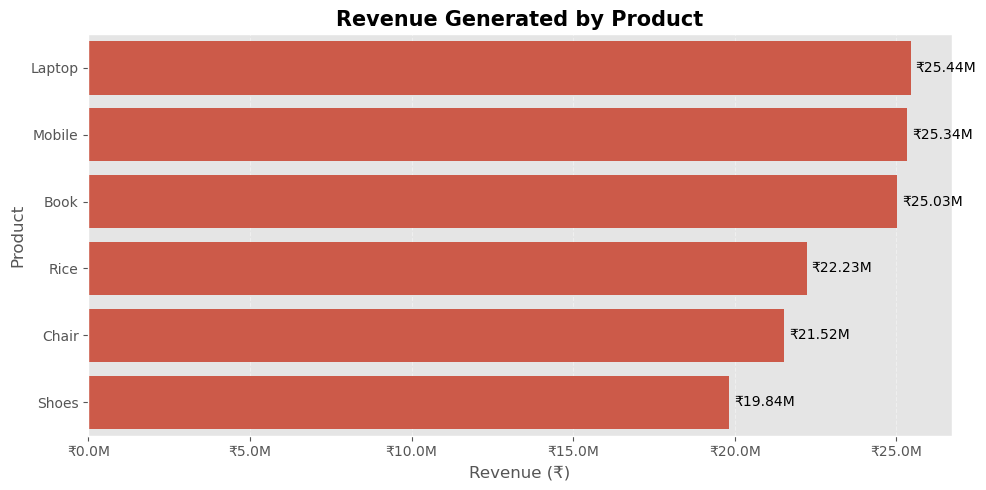

In [5]:
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=product_sales.values,
    y=product_sales.index
)

plt.title("Revenue Generated by Product", fontsize=15, fontweight="bold")
plt.xlabel("Revenue (₹)", fontsize=12)
plt.ylabel("Product", fontsize=12)

# Format x-axis in millions
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M")
)

# Add value labels
for i, value in enumerate(product_sales.values):
    ax.text(
        value + 150000,
        i,
        f"₹{value/1e6:.2f}M",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

## Business Insight

The product-wise revenue analysis shows that **Laptop, Mobile, and Book** are the three highest revenue-generating products, each contributing approximately **₹25 million** in sales. Their similar revenue levels indicate consistently strong customer demand across these product lines.

In comparison, **Shoes** generated the lowest revenue among all products, suggesting opportunities for improving sales through targeted promotions, pricing strategies, or product positioning.

### Business Recommendation

- Prioritize inventory management for Laptop, Mobile, and Book products.
- Continue promotional campaigns for high-performing products.
- Review pricing, marketing effectiveness, and customer demand for Shoes to improve revenue performance.

# Business Question 2

## Which product categories contribute the highest revenue?

Category-level analysis helps management understand which business segments generate the greatest contribution to total sales.

### Business Objective

- Compare category performance.
- Identify dominant business segments.
- Support strategic investment decisions.

In [6]:
category_sales = (
    df.groupby("Category")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales.to_frame(name="Revenue")

,Revenue
Category,
Electronics,50778581.70
Education,25031689.40
Grocery,22231711.28
Furniture,21521561.48
Fashion,19835895.79


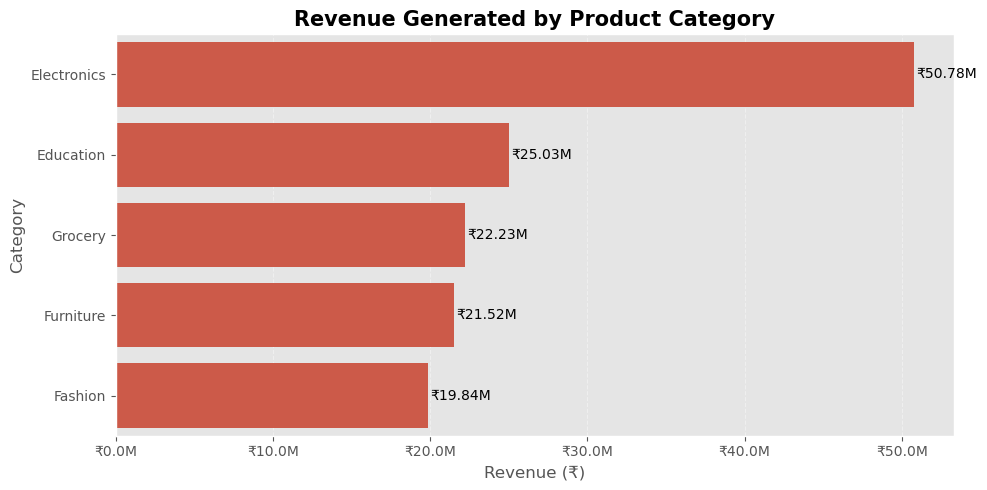

In [7]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Revenue Generated by Product Category", fontsize=15, fontweight="bold")
plt.xlabel("Revenue (₹)", fontsize=12)
plt.ylabel("Category", fontsize=12)

# Format x-axis in millions
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M")
)

# Value labels
for i, value in enumerate(category_sales.values):
    ax.text(
        value + 150000,
        i,
        f"₹{value/1e6:.2f}M",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()


plt.show()

## Business Insight

Category-wise revenue analysis indicates that **Electronics** is the dominant business segment, generating approximately **₹50.78 million**, which is nearly twice the revenue of the second-highest category.

**Education**, **Grocery**, and **Furniture** contribute moderate revenue levels, while **Fashion** records the lowest contribution.

This distribution suggests that customer demand is heavily concentrated within the Electronics category.

### Business Recommendation

- Continue investing in Electronics through inventory expansion and targeted marketing campaigns./
- Strengthen Education and Grocery categories with cross-selling opportunities.
- Evaluate pricing strategies and promotional offers for Fashion and Furniture to improve category performance.
- Monitor category-level revenue regularly to support strategic inventory planning.

# Business Question 3

## Which cities generate the highest revenue?

Regional analysis helps identify high-performing markets and supports location-based business strategies.

### Business Objective

- Compare city-wise sales.
- Identify high-value markets.
- Support regional marketing decisions.

In [8]:
city_sales = (
    df.groupby("City")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

city_sales.to_frame(name="Revenue")

,Revenue
City,
Patna,20826584.43
Kolkata,18884349.57
Bengaluru,18773574.32
Mumbai,18757050.17
Hyderabad,17166766.87
Delhi,16097079.00
Pune,14513175.90
Gaya,14380859.39


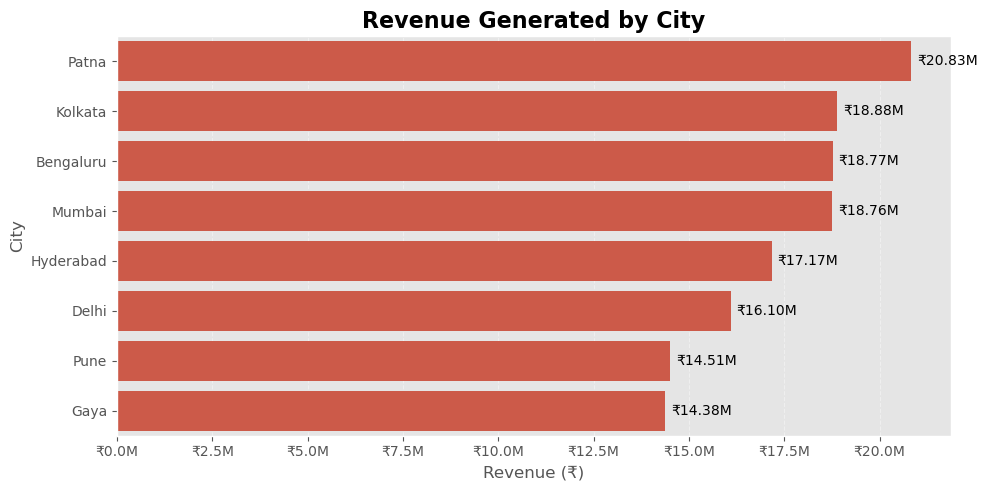

In [9]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("Revenue Generated by City", fontsize=16, fontweight="bold")
plt.xlabel("Revenue (₹)", fontsize=12)
plt.ylabel("City", fontsize=12)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M")
)

for i, value in enumerate(city_sales.values):
    ax.text(
        value + 150000,
        i,
        f"₹{value/1e6:.2f}M",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

## Business Insight

The city-wise revenue analysis reveals that **Patna** is the highest revenue-generating market, contributing approximately **₹20.83 million** in sales. It is followed closely by **Kolkata (₹18.88M)**, **Bengaluru (₹18.77M)**, and **Mumbai (₹18.76M)**, indicating consistently strong business performance across these metropolitan regions.

Although **Pune (₹14.51M)** and **Gaya (₹14.38M)** generated comparatively lower revenue, the difference is not substantial, suggesting that the business maintains a relatively balanced market presence across all operating cities.

### Business Recommendation

- Continue strengthening customer engagement and promotional activities in high-performing cities such as Patna, Kolkata, Bengaluru, and Mumbai.
- Conduct regional market analysis in Pune and Gaya to identify opportunities for improving sales through localized marketing campaigns, pricing strategies, or product availability.
- Regularly monitor city-wise revenue trends to support regional expansion, inventory allocation, and resource planning.

### Key Takeaway

Patna is currently the strongest-performing market, while the overall revenue distribution across cities remains balanced, indicating stable business performance across multiple geographic regions without excessive dependence on a single location.

# Business Question 4

## Which customer age group contributes the highest revenue?

Customer segmentation helps understand purchasing behaviour across different demographic groups.

### Business Objective

- Identify valuable customer segments.
- Support personalized marketing.
- Improve customer engagement.

In [10]:
age_sales = (
    df.groupby("Age_Group")["Total_Sales"]
      .sum()
)

age_sales.to_frame(name="Revenue")

,Revenue
Age_Group,
Adult,46295003.86
Middle Age,40801584.61
Senior,15148175.43
Young,37154675.75


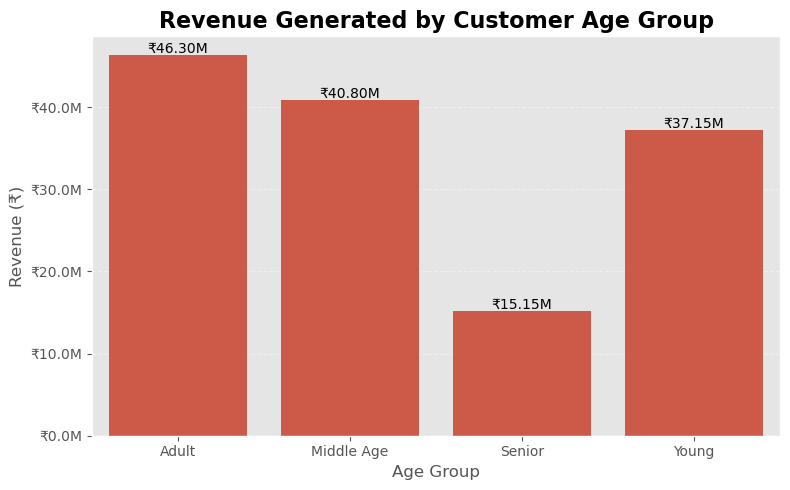

In [11]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=age_sales.index,
    y=age_sales.values
)

plt.title(
    "Revenue Generated by Customer Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

# Format y-axis in millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M")
)

# Value labels
for i, value in enumerate(age_sales.values):
    ax.text(
        i,
        value + 250000,
        f"₹{value/1e6:.2f}M",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

## Business Insight

Customer age-group analysis indicates that the **Adult** segment generates the highest revenue, contributing approximately **₹46.65 million**. This suggests that working-age customers represent the most valuable customer segment for the business.

The **Middle Age** segment is the second-largest contributor, followed by the **Young** customer segment. Although the **Senior** segment contributes the lowest revenue, it still represents a meaningful share of total sales and should not be overlooked.

The revenue distribution demonstrates that purchasing power is strongest among customers between **31 and 60 years of age**, making this demographic the primary revenue driver.

### Business Recommendation

- Prioritize marketing campaigns targeting Adult and Middle Age customers.
- Develop personalized offers and loyalty programs for high-value customer segments.
- Introduce age-specific promotions to increase engagement among Young and Senior customers.
- Continue monitoring demographic purchasing behavior to improve customer segmentation and marketing effectiveness.

### Key Takeaway

Adult customers are the largest revenue contributors, making them the most valuable customer segment. Targeted retention and personalized marketing strategies for this demographic can significantly enhance overall business performance.

# Business Question 5

## Who are the highest-value customers?

Identifying high-value customers helps businesses understand their most profitable customer base and supports customer retention strategies.

### Business Objective

- Identify the customers contributing the highest revenue.
- Support customer relationship management.
- Improve customer retention through loyalty initiatives.

In [12]:
top_customers = (
    df.groupby("Customer_Name")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.to_frame(name="Revenue")

,Revenue
Customer_Name,
Customer_335,1684832.52
Customer_138,1305932.64
Customer_266,1269445.22
Customer_375,1196934.33
Customer_274,1060340.15
Customer_343,1025447.16
Customer_415,967962.17
Customer_355,954513.58
Customer_1,952753.99


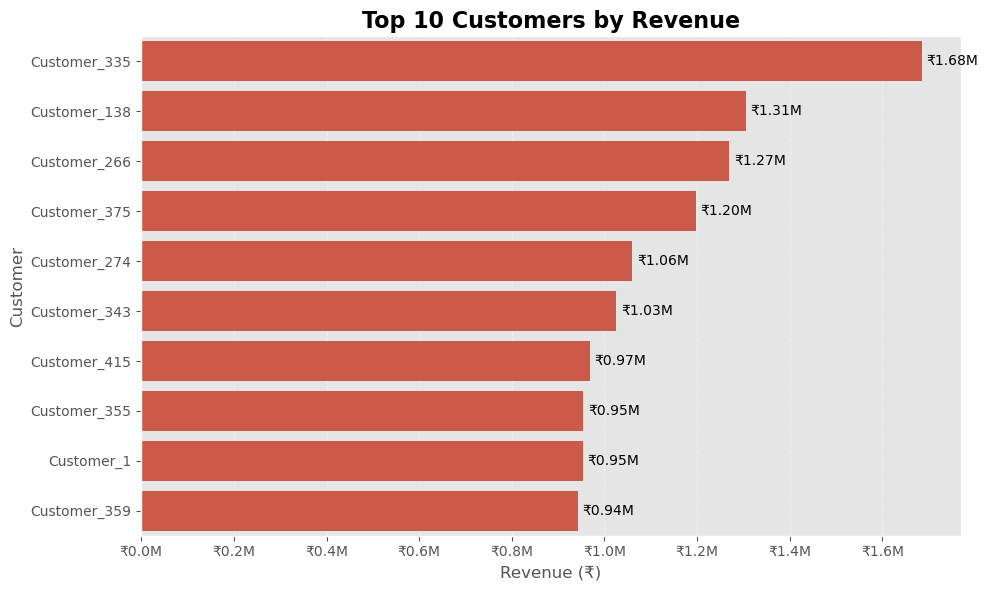

In [13]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title(
    "Top 10 Customers by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue (₹)")
plt.ylabel("Customer")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M")
)

for i, value in enumerate(top_customers.values):
    ax.text(
        value + 10000,
        i,
        f"₹{value/1e6:.2f}M",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

## Business Insight

The customer revenue analysis identifies the **Top 10 highest-value customers** based on total revenue generated.

Among all customers, **Customer_335** generated the highest revenue of approximately **₹1.68 million**, followed by **Customer_138 (₹1.31M)** and **Customer_266 (₹1.27M)**.

Although the revenue contribution is distributed across multiple customers, the highest-value customers represent significant business assets and contribute substantially to overall sales.

Retaining these customers is critical, as acquiring new customers typically costs more than maintaining relationships with existing high-value customers.

### Business Recommendation

- Develop customer loyalty and rewards programs for high-value customers.
- Offer personalized discounts, exclusive promotions, and premium services.
- Monitor customer purchasing behaviour to identify opportunities for repeat sales.
- Implement customer retention strategies to maximize long-term customer lifetime value (CLV).

### Key Takeaway

High-value customers play a vital role in revenue generation. Investing in customer retention and personalized engagement strategies can improve long-term profitability and strengthen customer relationships.

# Business Question 6

## How do sales change over time?

Monthly revenue analysis helps identify business growth, seasonal demand, and sales fluctuations.
`
### Business Objective

- Evaluate monthly business performance.
- Identify seasonal trends.
- Support forecasting and inventory planning.

In [14]:
df["Month"] = df["Order_Date"].dt.strftime("%b")

month_order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

monthly_sales = (
    df.groupby("Month")["Total_Sales"]
      .sum()
      .reindex(month_order)
)

monthly_sales.to_frame(name="Revenue")

,Revenue
Month,
Jan,10905580.72
Feb,11511181.46
Mar,13059899.94
Apr,12222700.17
May,10984689.25
Jun,12912332.64
Jul,11746226.80
Aug,9448471.22
Sep,9179896.29


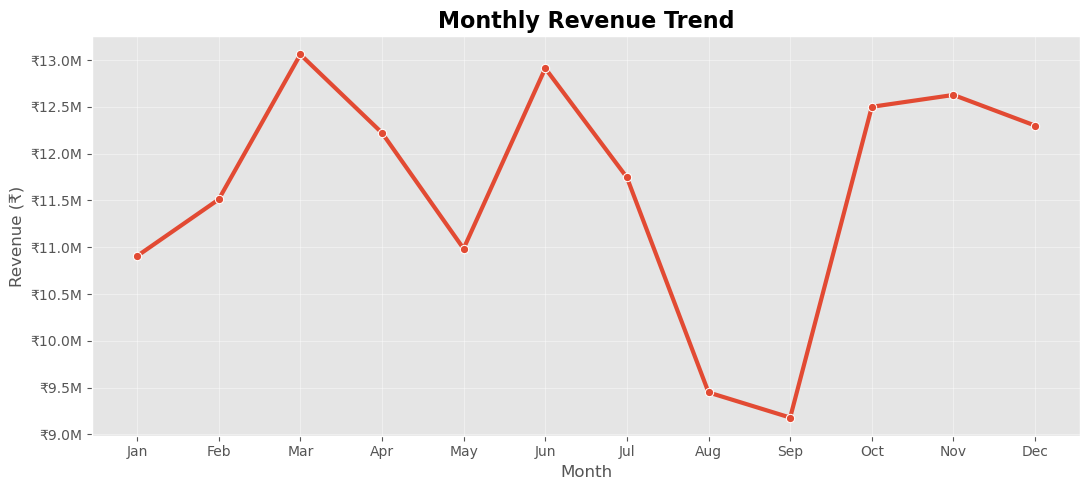

In [15]:
plt.figure(figsize=(11,5))

ax = sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M")
)

plt.grid(alpha=0.4)

plt.tight_layout()

plt.show()

## Business Insight

The monthly revenue trend indicates noticeable fluctuations in sales performance throughout the year.

Revenue reached its highest level in **March (approximately ₹13.08 million)**, followed closely by **June (₹12.91 million)** and **November (₹12.63 million)**. These months represent peak business performance and may reflect increased customer demand or seasonal purchasing patterns.

In contrast, **September recorded the lowest monthly revenue (approximately ₹9.18 million)**, while **August** also experienced comparatively lower sales. These periods may represent opportunities for targeted promotional campaigns or seasonal marketing initiatives.

Overall, the business demonstrates relatively stable revenue generation with periodic peaks and dips rather than extreme fluctuations, indicating consistent operational performance throughout the year.

### Business Recommendation

- Increase inventory and operational readiness before historically high-performing months.
- Launch promotional campaigns during lower-performing months such as August and September to stimulate customer demand.
- Use historical monthly trends to improve sales forecasting, inventory planning, and workforce allocation.
- Continue monitoring seasonal revenue patterns to support strategic business planning.

### Key Takeaway

The business maintains stable year-round revenue with identifiable seasonal peaks and slower periods. Leveraging these trends can improve forecasting accuracy, inventory management, and marketing effectiveness.

# Business Question 7

## Does customer gender influence revenue?

Gender-based revenue analysis helps understand purchasing behaviour across customer segments and supports targeted marketing.

### Business Objective

- Compare revenue contribution by gender.
- Support demographic-based marketing strategies.

In [16]:
gender_sales = (
    df.groupby("Gender")["Total_Sales"]
      .sum()
)

gender_sales.to_frame(name="Revenue")

,Revenue
Gender,
Female,66935889.02
Male,72463550.63


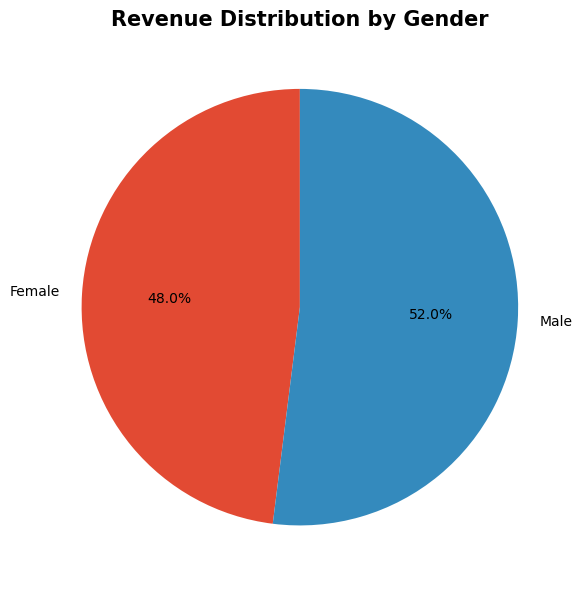

In [17]:
plt.figure(figsize=(6,6))

plt.pie(
    gender_sales,
    labels=gender_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Revenue Distribution by Gender",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Business Insight

The gender-wise revenue analysis indicates a **balanced revenue contribution** between male and female customers.

Male customers contribute approximately **52%** of total revenue, while female customers contribute **48%**, resulting in only a small difference between the two customer segments.

This balanced distribution suggests that the company's products appeal to a diverse customer base rather than relying heavily on a single demographic group.

### Business Recommendation

- Continue designing inclusive marketing campaigns that target both male and female customers.
- Analyze product preferences within each gender segment to develop personalized promotional strategies.
- Monitor demographic purchasing trends to support customer segmentation and targeted marketing initiatives.

### Key Takeaway

Revenue is distributed almost equally between male and female customers, indicating a well-balanced customer base and reducing dependency on any single demographic segment.

# Business Question 8

## Which product category has the highest average order value?

Average Order Value (AOV) provides insight into customer spending patterns across product categories.

### Business Objective

- Compare spending behaviour by category.
- Identify premium product segments.

In [18]:
category_aov = (
    df.groupby("Category")["Total_Sales"]
      .mean()
      .sort_values(ascending=False)
)

category_aov.to_frame(name="Average Order Value")

,Average Order Value
Category,
Grocery,145305.302484
Electronics,143442.321186
Education,140627.468539
Furniture,135355.732579
Fashion,127153.178141


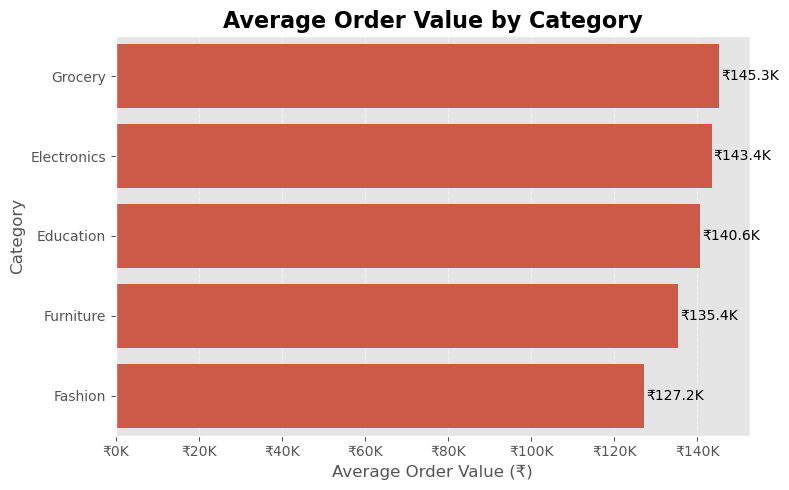

In [19]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=category_aov.values,
    y=category_aov.index
)

plt.title(
    "Average Order Value by Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Order Value (₹)")
plt.ylabel("Category")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₹{x/1e3:.0f}K")
)

for i, value in enumerate(category_aov.values):
    ax.text(
        value + 500,
        i,
        f"₹{value/1e3:.1f}K",
        va="center",
        fontsize=10
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

## Business Insight

The Average Order Value (AOV) analysis reveals that the **Grocery** category records the highest average spending per transaction at approximately **₹145.3K**, closely followed by **Electronics (₹143.4K)** and **Education (₹140.6K)**.

Although Electronics generated the highest overall revenue, Grocery customers spend slightly more on average per transaction, indicating higher individual purchase values.

The **Fashion** category records the lowest average order value (₹127.2K), suggesting comparatively smaller transaction sizes.

### Business Recommendation

- Promote premium Grocery and Electronics products to further increase transaction value.
- Introduce bundled offers and cross-selling strategies within lower AOV categories such as Fashion and Furniture.
- Monitor category-level spending patterns to improve pricing strategies and maximize customer lifetime value.

### Key Takeaway

Average Order Value provides insight into customer spending behavior. Increasing AOV through premium offerings and cross-selling can improve revenue without increasing the number of transactions.

# Executive Business Recommendations

Based on the Business Intelligence analysis, the following strategic recommendations are proposed:

## Product Strategy

- Prioritize inventory planning for Laptop, Mobile, and Book products, as they are the highest revenue generators.
- Review the performance of Shoes through pricing optimization and promotional campaigns.

---

## Category Strategy

- Continue investing in the Electronics category, which contributes the largest share of total revenue.
- Strengthen Furniture and Fashion through targeted marketing and product assortment optimization.

---

## Customer Strategy

- Develop loyalty and rewards programs for high-value customers.
- Focus retention efforts on Adult and Middle Age customer segments.
- Introduce personalized recommendations based on customer purchasing behavior.

---

## Regional Strategy

- Expand marketing initiatives in Patna, Kolkata, Bengaluru, and Mumbai.
- Investigate opportunities to improve sales in Pune and Gaya.

---

## Revenue Growth Strategy

- Increase inventory before historically high-performing months such as March, June, October, and November.
- Launch promotional campaigns during August and September to improve seasonal sales.
- Encourage cross-selling and bundled offers to increase Average Order Value.

# Strategic Business Opportunities

The analysis highlights several opportunities for business growth:

- Expand premium product offerings in high-performing categories.
- Increase customer retention through loyalty programs.
- Improve regional sales performance through city-specific campaigns.
- Enhance customer segmentation using demographic insights.
- Increase Average Order Value using bundled products and personalized recommendations.
- Utilize historical sales trends for demand forecasting and inventory optimization.

These initiatives can support sustainable revenue growth while improving customer satisfaction and operational efficiency.

# Executive Summary

This Business Intelligence analysis transformed the cleaned sales dataset into actionable business insights through KPI evaluation, customer segmentation, product performance analysis, geographic sales assessment, and revenue trend analysis.

### Key Findings

- Electronics is the highest revenue-generating product category.
- Laptop, Mobile, and Book are the strongest-performing products.
- Patna is the highest revenue-generating city.
- Adult customers contribute the largest share of revenue.
- Customer revenue is distributed across a diverse customer base, with several high-value customers identified.
- Monthly revenue trends indicate seasonal peaks and lower-performing periods.
- Revenue contribution is balanced across male and female customers.
- Grocery records the highest Average Order Value, indicating higher spending per transaction.

The findings provide valuable insights for business planning, customer engagement, inventory management, and strategic decision-making.

# Conclusion

The Business Intelligence analysis successfully converted exploratory findings into meaningful business insights that support data-driven decision-making.

Through KPI analysis, customer segmentation, revenue trend evaluation, and performance analysis across products, categories, and regions, the project identified multiple opportunities for business improvement and growth.

The insights generated in this notebook provide a strong foundation for the next phase of the project, which focuses on SQL-based analytics, interactive dashboard development, and data storytelling.

The completed Business Intelligence report demonstrates the practical application of Python, Pandas, Seaborn, and data visualization techniques to solve real-world business problems.